## Multi class logistic regression with categorical data

### About the dataset

**[Diamonds](https://www.kaggle.com/datasets/shivam2503/diamonds)**

Analyze diamonds by their cut, color, clarity, price, and other attributes

**Context**

This dataset contains the prices and other attributes of almost 54,000 diamonds. 

**Features**

- **price** price in US dollars (\$326--\$18,823)

- **carat** weight of the diamond (0.2--5.01)

- **cut** quality of the cut (Fair, Good, Very Good, Premium, Ideal)

- **color** diamond colour, from J (worst) to D (best)

- **clarity** a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))

- **x** length in mm (0--10.74)

- **y** width in mm (0--58.9)

- **z** depth in mm (0--31.8)

- **depth** total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)

- **table** width of top of diamond relative to widest point (43--95)

The target is 'cut', which has 5 classes: Ideal, Premium, Very Good, Good, and Fair (descending quality)

### Reading the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
diamonds = pd.read_csv("./diamonds.csv").drop("Unnamed: 0", axis=1)  # dropping the first column which is unnamed
diamonds.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [3]:
diamonds.shape

(53940, 10)

In [4]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [9]:
diamonds.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

### Basic EDA

#### Color

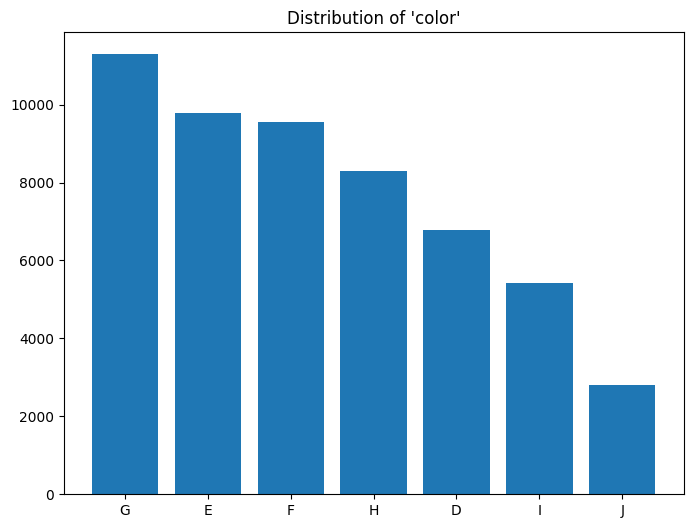

In [5]:
plt.figure(figsize=(8,6))
value_count = diamonds['color'].value_counts()
plt.bar(x = value_count.index, height=value_count.values.round(3))
plt.title("Distribution of 'color'")
plt.show()

In [6]:
value_count

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

#### clarity

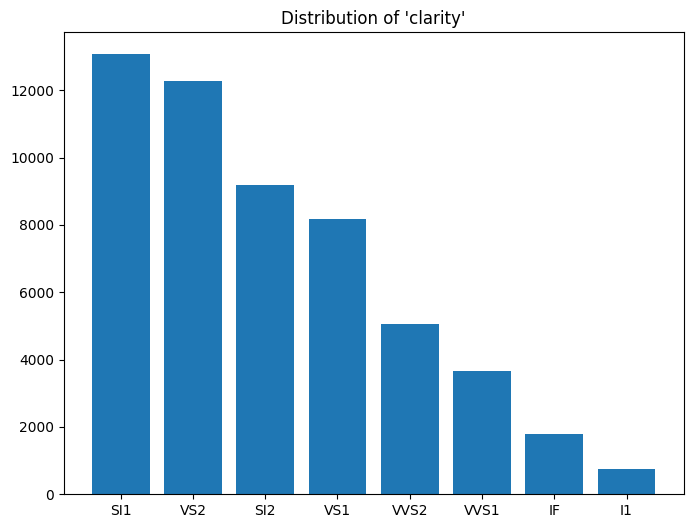

In [7]:
plt.figure(figsize=(8,6))
value_count = diamonds['clarity'].value_counts()
plt.bar(x = value_count.index, height=value_count.values.round(3))
plt.title("Distribution of 'clarity'")
plt.show()

In [8]:
diamonds.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.798,0.474,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749,1.433,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457,2.234,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.800,3989.440,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731,1.122,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.735,1.142,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.539,0.706,0.0,2.91,3.53,4.04,31.80


The above output shows the features are on different scales, suggesting we use some type of normalization. This step is essential for many linear models (like logistic regression) to perform well.

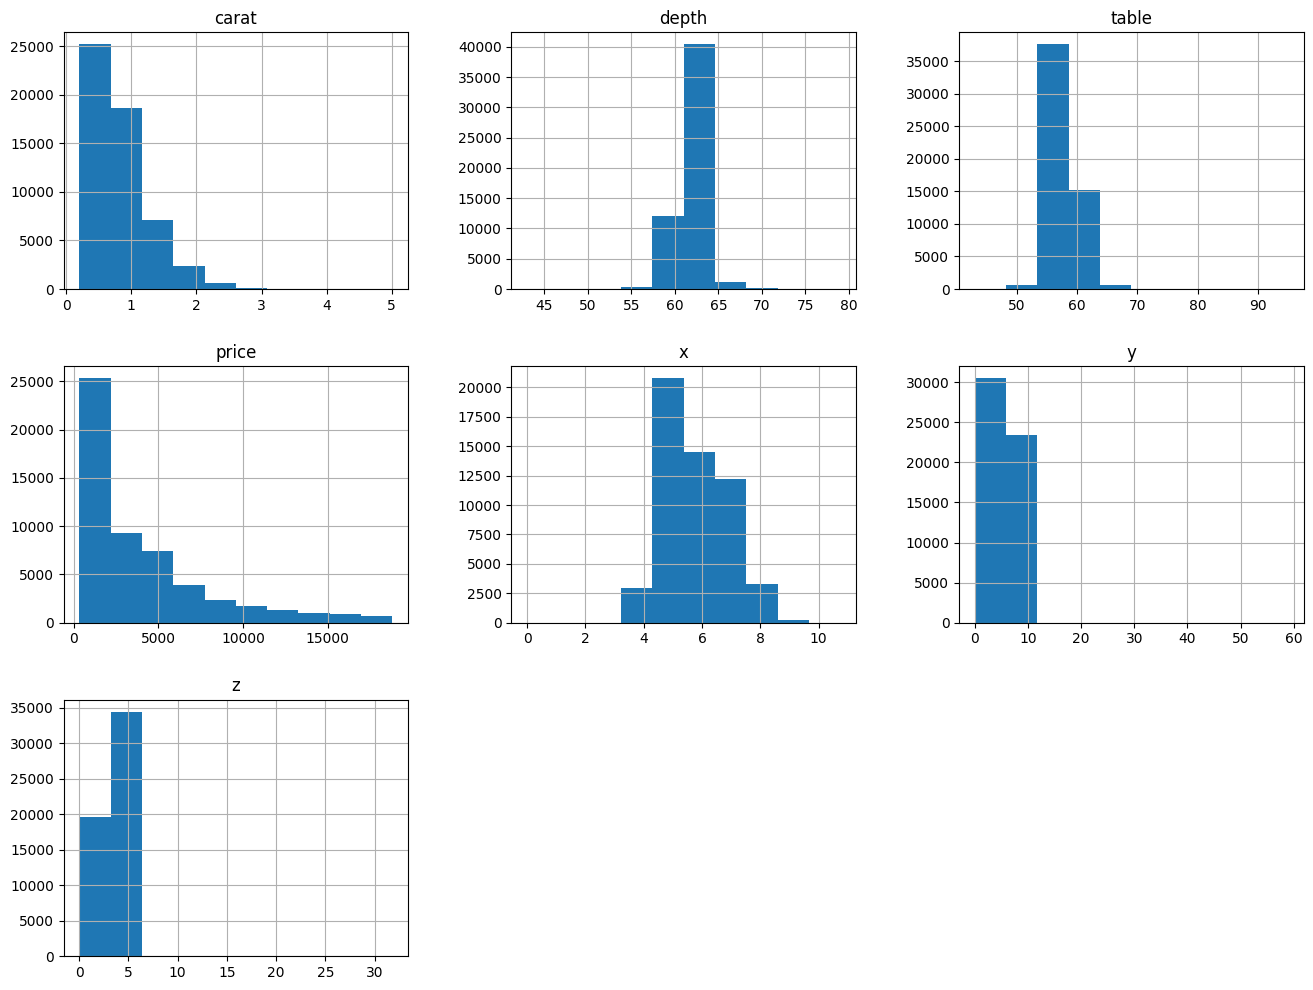

In [10]:
diamonds.hist(figsize=(16, 12));

#### Examine the target varaible

In [11]:
# Distribution of target variable

diamonds['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

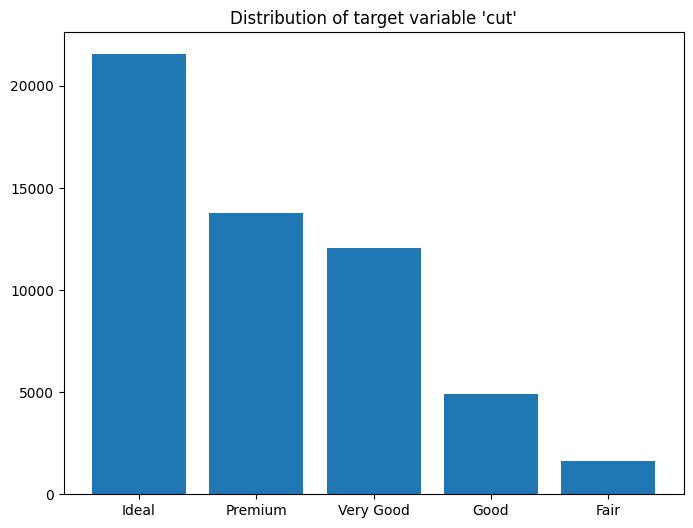

In [12]:
plt.figure(figsize=(8,6))
value_count = diamonds['cut'].value_counts()
plt.bar(x = value_count.index, height=value_count.values.round(3))
plt.title("Distribution of target variable 'cut'")
plt.show()

### Splitting the dataset into train and test and scaling / encoding features

In [13]:
from sklearn.model_selection import train_test_split

X = diamonds.drop('cut', axis=1)      # taking all the features except cut
y = diamonds['cut'].values.flatten() 

# Create train/test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=123, test_size=0.3, stratify=y    # startified based on target variable, so that the distribution of the target variable is same in train and test dataset
)

In [14]:
X_train.shape, X_test.shape

((37758, 9), (16182, 9))

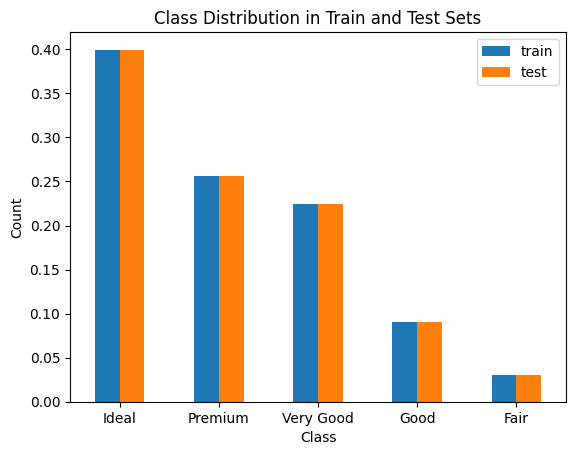

In [15]:
# Check the distribution of target variable in train and test dataset 
# This is to check the distribution of target variable is similar

df = pd.DataFrame({'train': pd.Series(y_train).value_counts(normalize=True),
                   'test': pd.Series(y_test).value_counts(normalize=True)})

df.plot(kind='bar')
plt.title('Class Distribution in Train and Test Sets')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Understanding Data Preprocessing in scikit-learn

When working with machine learning, it’s important to preprocess your data. scikit-learn provides powerful tools to make this process easy and organized. Here’s a quick guide to the main concepts:

---

#### 1. Pipeline

A **Pipeline** is a way to chain multiple data processing steps together, so you can treat them as a single object. This makes your code cleaner and helps avoid data leakage.

- **Why use it?**  
  Ensures that all preprocessing steps are applied in the correct order, both during training and testing.
- **Learn more:**  
  [scikit-learn Pipeline documentation](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)

---

#### 2. make_pipeline

**make_pipeline** is a helper function to quickly create a pipeline without naming each step.

- **Why use it?**  
  It’s faster and easier for simple pipelines.
- **Learn more:**  
  [scikit-learn make_pipeline documentation](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)

---

#### 3. Transformer

A **Transformer** is any object (usually a class) that can transform data. It must have `.fit()` and `.transform()` methods.

- **Examples:**  
  StandardScaler, OneHotEncoder, etc.
- **Learn more:**  
  [scikit-learn TransformerMixin documentation](https://scikit-learn.org/stable/modules/generated/sklearn.base.TransformerMixin.html)

---

#### 4. ColumnTransformer

A **ColumnTransformer** allows you to apply different preprocessing steps to different columns of your data (e.g., scale numeric columns, encode categorical columns).

- **Why use it?**  
  Real-world datasets often have both numeric and categorical features that need different preprocessing.
- **Learn more:**  
  [scikit-learn ColumnTransformer documentation](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html)

---

#### 5. OneHotEncoder

**OneHotEncoder** converts categorical variables into a format that can be provided to ML algorithms (one-hot encoding).

- **Why use it?**  
  Many algorithms require numeric input, so categories are converted to binary columns.
- **Learn more:**  
  [scikit-learn OneHotEncoder documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

---

#### 6. StandardScaler

**StandardScaler** standardizes features by removing the mean and scaling to unit variance.

- **Why use it?**  
  Many ML algorithms work better when features are on a similar scale.
- **Learn more:**  
  [scikit-learn StandardScaler documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

---

#### Example Workflow

Here’s how you might use these tools together:

```python
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline

# Example: numeric features and categorical features
numeric_features = ['age', 'salary']
categorical_features = ['gender', 'city']

# Create transformers for each type
numeric_transformer = make_pipeline(StandardScaler())
categorical_transformer = make_pipeline(OneHotEncoder())

# Combine them using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
```


This setup ensures your data is preprocessed correctly and efficiently, ready for machine learning models!


In [16]:
X.dtypes

carat      float64
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

# Build categorical preprocessor
categorical_cols = X.select_dtypes(include="object").columns.to_list()  
print(f"categorical columns: {categorical_cols}") # list of categorical columns
categorical_pipe = make_pipeline(OneHotEncoder(sparse_output=False, handle_unknown="ignore"))

# Build numeric processor
numerical_cols_1 = ["price", "carat"] 
numerical_cols_2 = ["x", "y", "z", "depth", "table"]
numeric_pipe_1 = make_pipeline(MinMaxScaler())
numeric_pipe_2 = make_pipeline(StandardScaler())

# Full processor
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipe, categorical_cols),     # apply cateorical transformation on categorical column
        ("min-max-scaling", numeric_pipe_1, numerical_cols_1),   # apply min-max scaling to the numerical_cols_1
        ("standardization", numeric_pipe_2, numerical_cols_2)    # apply standradization to the numerical_cols_2
    ]
)

categorical columns: ['color', 'clarity']


In [18]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('min-max-scaling', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [19]:
X_train = preprocessor.fit_transform(X_train)    # first fit and then transform
X_test = preprocessor.transform(X_test)          # only transform

In [20]:
X_train[0]

array([ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.08022923,  0.06444906, -0.57404459, -0.53205664, -0.46629264,
        0.73417143, -1.99349261])

In [22]:
len(X_train[0])

22

In [21]:
X_test[0]

array([ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.03200519,  0.02494802, -1.18689718, -1.1362511 , -1.11240641,
        0.24622534, -1.09876616])

### Logistic Regression with OvR (One vs Rest)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [25]:
LR_model_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, penalty=None)) # creating the model

In [26]:
LR_model_ovr.fit(X_train, y_train)   # training the model

c:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-2025\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-2025\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre... penalty=None)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeig

In [27]:
# predicting on train and test dataset

y_train_predict = LR_model_ovr.predict(X_train)
y_test_predict = LR_model_ovr.predict(X_test)

In [28]:
# measuring the performance

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [29]:
# On train dataset

print(classification_report(y_train, y_train_predict))

              precision    recall  f1-score   support

        Fair       0.90      0.44      0.59      1127
        Good       0.44      0.01      0.02      3434
       Ideal       0.71      0.90      0.79     15086
     Premium       0.66      0.72      0.69      9654
   Very Good       0.50      0.44      0.47      8457

    accuracy                           0.65     37758
   macro avg       0.64      0.50      0.51     37758
weighted avg       0.63      0.65      0.62     37758



In [30]:
accuracy_score(y_train, y_train_predict)

0.6544838179988347

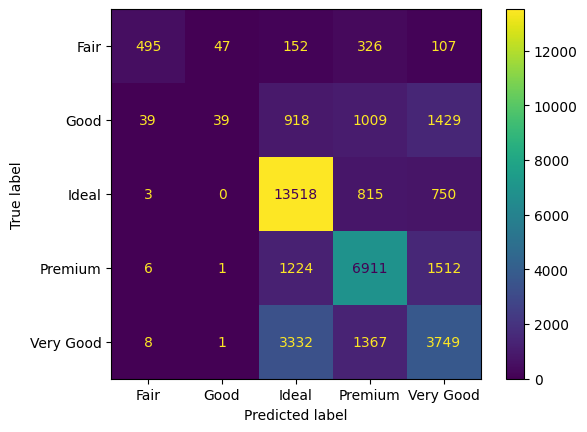

In [31]:
cm_train = confusion_matrix(y_train, y_train_predict, labels=LR_model_ovr.classes_)

ConfusionMatrixDisplay(cm_train, display_labels=LR_model_ovr.classes_).plot();

In [32]:
# On test dataset

print(classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

        Fair       0.92      0.43      0.58       483
        Good       0.45      0.01      0.02      1472
       Ideal       0.71      0.89      0.79      6465
     Premium       0.65      0.70      0.68      4137
   Very Good       0.49      0.45      0.47      3625

    accuracy                           0.65     16182
   macro avg       0.64      0.50      0.51     16182
weighted avg       0.63      0.65      0.61     16182



In [33]:
accuracy_score(y_test, y_test_predict)

0.6515881844024225

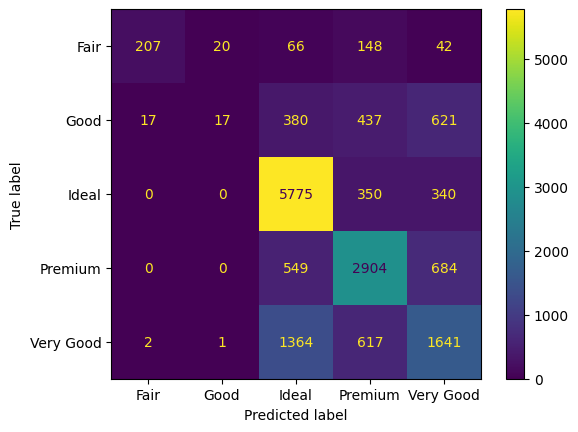

In [34]:
cm_test = confusion_matrix(y_test, y_test_predict, labels=LR_model_ovr.classes_)

ConfusionMatrixDisplay(cm_test, display_labels=LR_model_ovr.classes_).plot();

### Multinomial Logistic Regression

By default the `LogisticRegression` class of sklearn will use `multinomial` method for multi-class classification when `n_classes >= 3`. Learn more about it [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [35]:
LR_model_multinomial = LogisticRegression(penalty=None, max_iter=1000)

LR_model_multinomial.fit(X_train, y_train)

c:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-2025\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [36]:
# predicting on train and test dataset

y_train_predict = LR_model_multinomial.predict(X_train)
y_test_predict = LR_model_multinomial.predict(X_test)

In [37]:
# On train dataset

print(classification_report(y_train, y_train_predict))

              precision    recall  f1-score   support

        Fair       0.76      0.51      0.61      1127
        Good       0.56      0.12      0.20      3434
       Ideal       0.72      0.85      0.78     15086
     Premium       0.66      0.72      0.69      9654
   Very Good       0.50      0.46      0.48      8457

    accuracy                           0.66     37758
   macro avg       0.64      0.53      0.55     37758
weighted avg       0.64      0.66      0.63     37758



In [38]:
accuracy_score(y_train, y_train_predict)

0.6552253827003549

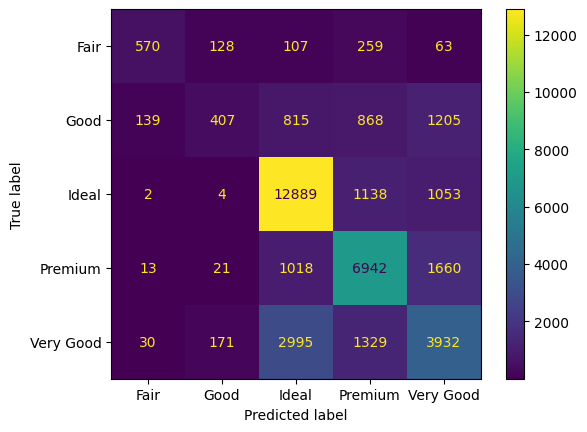

In [39]:
cm_train = confusion_matrix(y_train, y_train_predict, labels=LR_model_ovr.classes_)

ConfusionMatrixDisplay(cm_train, display_labels=LR_model_ovr.classes_).plot();

In [40]:
# On test dataset

print(classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

        Fair       0.76      0.49      0.59       483
        Good       0.55      0.13      0.22      1472
       Ideal       0.73      0.85      0.78      6465
     Premium       0.65      0.71      0.68      4137
   Very Good       0.49      0.47      0.48      3625

    accuracy                           0.65     16182
   macro avg       0.64      0.53      0.55     16182
weighted avg       0.64      0.65      0.63     16182



In [41]:
accuracy_score(y_test, y_test_predict)

0.6525769373377828

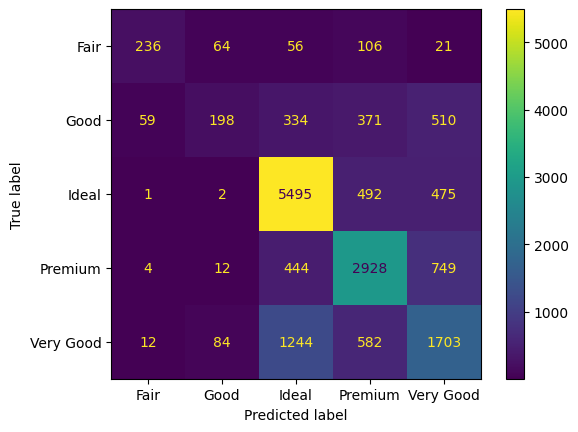

In [42]:
cm_test = confusion_matrix(y_test, y_test_predict, labels=LR_model_ovr.classes_)

ConfusionMatrixDisplay(cm_test, display_labels=LR_model_ovr.classes_).plot();